# Notebook 10 — Piano Movement Analysis (Advanced)

Goes beyond hit/miss counts to analyse the **spatial and temporal structure** of keyboard movements
and **per-finger kinematics**.

| Metric | What it measures | Clinical relevance |
|---|---|---|
| **Key transition distance** | Reach distance between keypresses | Upper-limb range of motion |
| **Direction bias** | Left vs right movement preference | Lateral motor asymmetry |
| **Per-finger RT** | Reaction speed per individual finger | Fine motor dexterity mapping |
| **Wrong-finger rate** | Using wrong finger | Finger individuation (independence) |
| **Spatial key layout** | Where on keyboard errors cluster | Specific finger/reach weakness |
| **RT variability (std)** | Consistency of reaction speed | Motor control stability |

| Audience | What they get |
|---|---|
| **User / Patient** | Which fingers are weakest and how consistent you are |
| **Doctor / Clinician** | Finger individuation, bilateral symmetry, reach range |
| **HCI Researcher** | Spatial error maps, RT distributions, finger-specific biomarkers |
| **App maker** | Which key pairs and distances cause most errors → level design feedback |


In [24]:
DATA_DIR    = '.'
OUT_DIR     = 'outputs'
GROUP_LABEL = 'Group A'
import os, json, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as sp
warnings.filterwarnings('ignore')
os.makedirs(OUT_DIR, exist_ok=True)
sys.path.insert(0, os.path.dirname(os.path.abspath('hci_utils.py')))
from hci_utils import (load_board_tries, load_bd_sessions, load_piano_sessions,
                        load_piano_movements, load_finger_movements,
                        build_key_position_map, compare_groups, save_fig,
                        SHAPE_ORDER, HAND_COLORS, GROUP_COLORS)

sessions, keypresses = load_piano_sessions(DATA_DIR)
movements  = load_piano_movements(DATA_DIR)
fingers    = load_finger_movements(DATA_DIR)
key_map    = build_key_position_map(DATA_DIR)
valid_sess = sessions[sessions['is_valid']].copy().reset_index(drop=True)

print(f'Sessions: {len(sessions)} total, {len(valid_sess)} valid')
print(f'Key transitions (laptopMovements): {len(movements)}')
print(f'Finger movements (mobileMovements): {len(fingers)}')
print(f'Key positions mapped: {sorted(key_map.keys())}')


Sessions: 5 total, 4 valid
Key transitions (laptopMovements): 32
Finger movements (mobileMovements): 36
Key positions mapped: ['A', 'D', 'F', 'J', 'K', 'L', 'S']


## 1 · Fig 10a — Spatial keyboard layout with error rates
Shows where on the actual keyboard the keys are (in screen pixels) and how accurately each was reached.

Saved -> outputs/fig10a_keyboard_spatial_accuracy.png


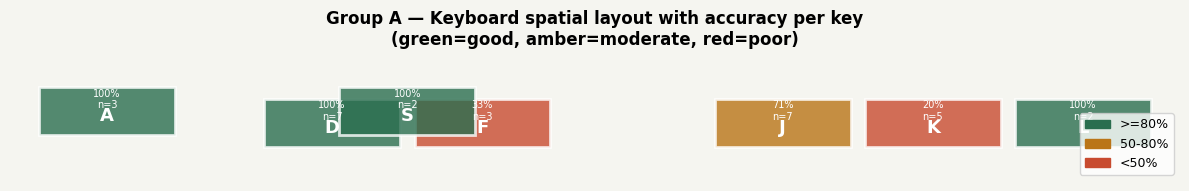


=== CLINICAL INSIGHT ===
Worst key: none (0% accuracy)
Best key:  A  (100% accuracy)


In [25]:
if movements.empty or not key_map:
    print('No movement data available yet.')
else:
    # Build per-key error rate from mobileMovements
    if not fingers.empty:
        key_acc = fingers.groupby('key').agg(
            n=('correct','count'), correct=('correct','sum')).reset_index()
        key_acc['acc'] = key_acc['correct'] / key_acc['n'] * 100
        key_acc_dict = dict(zip(key_acc['key'], key_acc['acc']))
    else:
        key_acc_dict = {}

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_facecolor('#f5f5f0')
    fig.patch.set_facecolor('#f5f5f0')

    for key, (x, y) in key_map.items():
        if x is None or np.isnan(x): continue
        acc = key_acc_dict.get(key, 50)      # default 50% if no data
        n   = key_acc.loc[key_acc['key']==key,'n'].values[0] if key in key_acc_dict else 0
        color = '#2a6e4f' if acc >= 80 else '#ba7517' if acc >= 50 else '#c84b2f'
        # draw key rectangle
        rect = plt.Rectangle((x-70, y-25), 140, 50,
                               facecolor=color, edgecolor='white', lw=2, alpha=0.8)
        ax.add_patch(rect)
        ax.text(x, y-5, key, ha='center', va='center', fontsize=13, fontweight='bold',
                color='white')
        ax.text(x, y+12,
                f'{acc:.0f}%\nn={n}' if n > 0 else '?',
                ha='center', va='center', fontsize=7, color='white')

    all_x = [v[0] for v in key_map.values() if v[0] is not None and not np.isnan(v[0])]
    all_y = [v[1] for v in key_map.values() if v[1] is not None and not np.isnan(v[1])]
    ax.set_xlim(min(all_x)-100, max(all_x)+100)
    ax.set_ylim(min(all_y)-60, max(all_y)+60)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(GROUP_LABEL + ' — Keyboard spatial layout with accuracy per key\n'
                 '(green=good, amber=moderate, red=poor)',  fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#2a6e4f',label='>=80%'),
                       Patch(color='#ba7517',label='50-80%'),
                       Patch(color='#c84b2f',label='<50%')],
              loc='lower right', fontsize=9)
    plt.tight_layout()
    save_fig(fig, 'fig10a_keyboard_spatial_accuracy.png', OUT_DIR)
    plt.show()
    print('\n=== CLINICAL INSIGHT ===')
    if key_acc_dict:
        worst_key = min(key_acc_dict, key=key_acc_dict.get)
        best_key  = max(key_acc_dict, key=key_acc_dict.get)
        print(f'Worst key: {worst_key} ({key_acc_dict[worst_key]:.0f}% accuracy)')
        print(f'Best key:  {best_key}  ({key_acc_dict[best_key]:.0f}% accuracy)')


## 2 · Fig 10b — Per-finger accuracy and response time

Saved -> outputs/fig10b_per_finger_kinematics.png


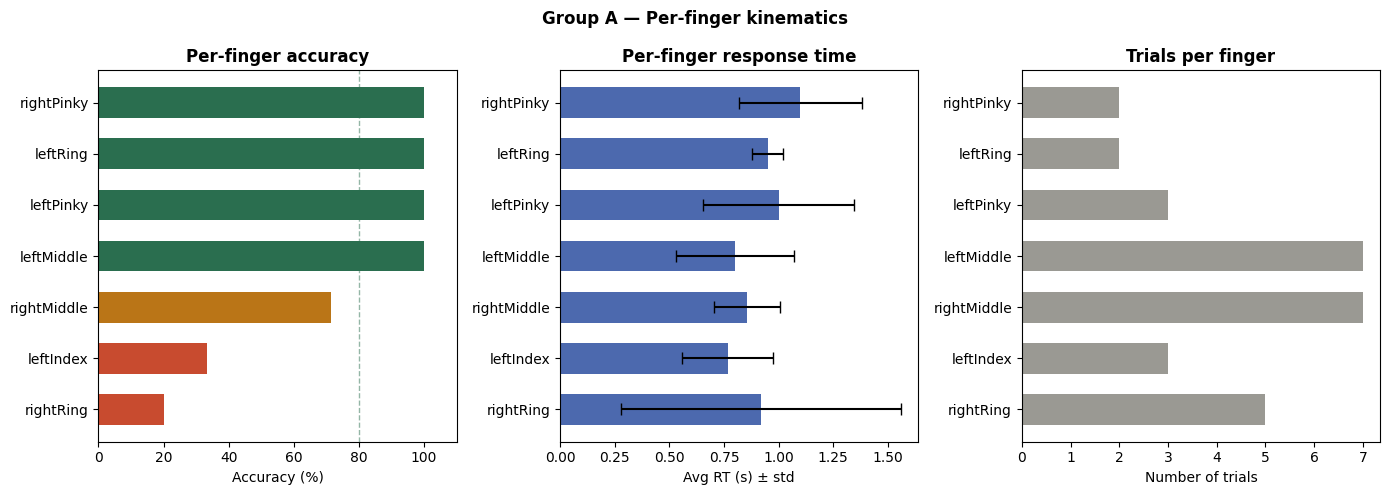


=== CLINICAL INSIGHT ===
Weakest finger:  rightRing — 20% accuracy, 0.92s avg RT
Strongest finger: leftMiddle — 100% accuracy, 0.80s avg RT

=== RESEARCH NOTE ===
High RT std for one finger = inconsistent motor control for that finger.
Map finger names to anatomical labels (thumb=thumb, index, middle, ring, pinky)
for clinical report language.


In [26]:
if fingers.empty:
    print('No mobileMovements data yet.')
else:
    facc = fingers.groupby('finger').agg(
        n=('correct','count'),
        correct=('correct','sum'),
        avg_rt=('responsetime','mean'),
        std_rt=('responsetime','std'),
    ).reset_index()
    facc['accuracy'] = facc['correct'] / facc['n'] * 100
    facc['std_rt']   = facc['std_rt'].fillna(0)
    facc = facc[facc['finger'] != 'none'].sort_values('accuracy')

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    # accuracy
    colors = ['#2a6e4f' if v >= 80 else '#ba7517' if v >= 50 else '#c84b2f'
              for v in facc['accuracy']]
    axes[0].barh(facc['finger'], facc['accuracy'], color=colors, height=0.6)
    axes[0].axvline(80, color='#2a6e4f', ls='--', lw=1, alpha=0.5)
    axes[0].set_xlabel('Accuracy (%)'); axes[0].set_xlim(0, 110)
    axes[0].set_title('Per-finger accuracy', fontweight='bold')

    # response time with std error bars
    axes[1].barh(facc['finger'], facc['avg_rt'], color='#2c4fa0', height=0.6, alpha=0.85)
    axes[1].errorbar(facc['avg_rt'], range(len(facc)),
                     xerr=facc['std_rt'], fmt='none', color='black', capsize=4, lw=1.5)
    axes[1].set_xlabel('Avg RT (s) ± std')
    axes[1].set_title('Per-finger response time', fontweight='bold')

    # trial count
    axes[2].barh(facc['finger'], facc['n'], color='#888780', height=0.6, alpha=0.85)
    axes[2].set_xlabel('Number of trials')
    axes[2].set_title('Trials per finger', fontweight='bold')

    plt.suptitle(GROUP_LABEL + ' — Per-finger kinematics', fontweight='bold')
    plt.tight_layout()
    save_fig(fig, 'fig10b_per_finger_kinematics.png', OUT_DIR)
    plt.show()

    print('\n=== CLINICAL INSIGHT ===')
    worst_f = facc.loc[facc['accuracy'].idxmin()]
    best_f  = facc.loc[facc['accuracy'].idxmax()]
    print(f'Weakest finger:  {worst_f["finger"]} — {worst_f["accuracy"]:.0f}% accuracy, '
          f'{worst_f["avg_rt"]:.2f}s avg RT')
    print(f'Strongest finger: {best_f["finger"]} — {best_f["accuracy"]:.0f}% accuracy, '
          f'{best_f["avg_rt"]:.2f}s avg RT')
    print('\n=== RESEARCH NOTE ===')
    print('High RT std for one finger = inconsistent motor control for that finger.')
    print('Map finger names to anatomical labels (thumb=thumb, index, middle, ring, pinky)')
    print('for clinical report language.')


## 3 · Fig 10c — Finger individuation: confusion matrix
Which finger does the user actually press when a specific finger is expected?
Diagonal = correct. Off-diagonal = wrong finger used (individuation failure).

Wrong-finger presses: 11 of 36 total (30.6%)
Saved -> outputs/fig10c_finger_confusion_matrix.png


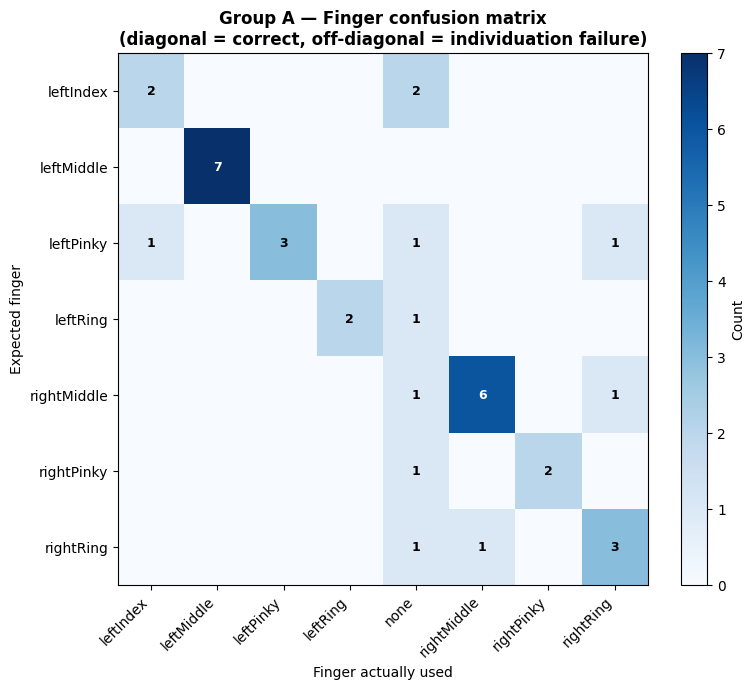


=== CLINICAL INSIGHT ===
Off-diagonal entries = finger individuation failure.
Common in neurological conditions (stroke, Parkinsons, MS).
Track total off-diagonal count over sessions as a recovery metric.
Most common confusion: expected leftIndex, used none


In [27]:
if fingers.empty:
    print('No mobileMovements data yet.')
else:
    wrong = fingers[fingers['finger'] != fingers['expectedFinger']]
    print(f'Wrong-finger presses: {len(wrong)} of {len(fingers)} total '
          f'({len(wrong)/len(fingers)*100:.1f}%)')

    pivot = fingers.groupby(['expectedFinger','finger']).size().unstack(fill_value=0)
    # sort by expectedFinger
    pivot = pivot.sort_index()

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')

    # annotate cells
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if val > 0:
                ax.text(j, i, str(val), ha='center', va='center',
                        color='white' if val > pivot.values.max()*0.5 else 'black',
                        fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    plt.colorbar(im, ax=ax, label='Count')
    ax.set_xlabel('Finger actually used')
    ax.set_ylabel('Expected finger')
    ax.set_title(GROUP_LABEL + ' — Finger confusion matrix\n'
                 '(diagonal = correct, off-diagonal = individuation failure)',
                 fontweight='bold')
    plt.tight_layout()
    save_fig(fig, 'fig10c_finger_confusion_matrix.png', OUT_DIR)
    plt.show()

    print('\n=== CLINICAL INSIGHT ===')
    print('Off-diagonal entries = finger individuation failure.')
    print('Common in neurological conditions (stroke, Parkinsons, MS).')
    print('Track total off-diagonal count over sessions as a recovery metric.')
    if len(wrong) > 0:
        most_confused = (wrong.groupby(['expectedFinger','finger'])
                         .size().sort_values(ascending=False).index[0])
        print(f'Most common confusion: expected {most_confused[0]}, used {most_confused[1]}')


## 4 · Fig 10d — Key transition direction bias
Are left-reaching or right-reaching movements more common? More accurate?

Saved -> outputs/fig10d_direction_bias.png


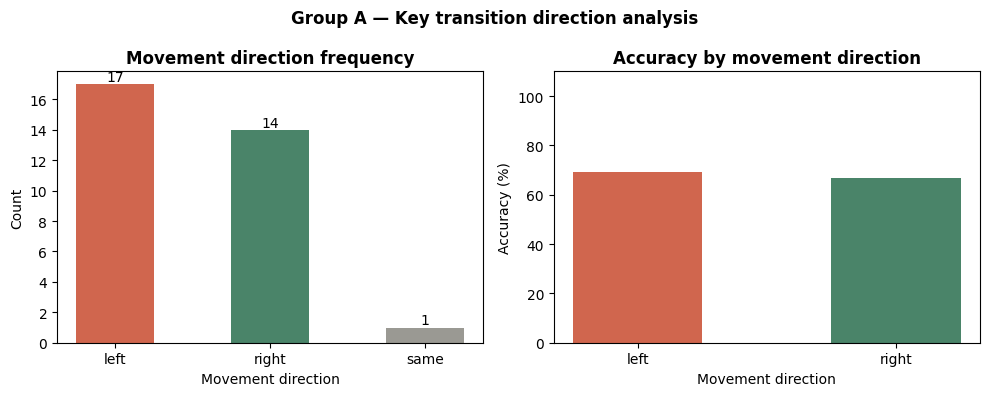


=== CLINICAL INSIGHT ===
Left-reach movements:  53.1%
Right-reach movements: 43.8%


In [28]:
if movements.empty:
    print('No movement data.')
else:
    dir_counts = movements['direction'].value_counts()
    dir_acc = {}
    if not fingers.empty:
        # merge movements with fingers by session and index — approximate by session order
        for sess in movements['session_id'].unique():
            mv = movements[movements['session_id']==sess].reset_index(drop=True)
            fi = fingers[fingers['session_id']==sess].reset_index(drop=True)
            n  = min(len(mv), len(fi))
            for i in range(n):
                d = mv.loc[i,'direction']
                c_ = fi.loc[i,'correct']
                if d not in dir_acc: dir_acc[d] = []
                dir_acc[d].append(c_)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # frequency
    axes[0].bar(dir_counts.index, dir_counts.values,
                color=['#c84b2f','#2a6e4f','#888780'], alpha=0.85, width=0.5)
    axes[0].set_xlabel('Movement direction'); axes[0].set_ylabel('Count')
    axes[0].set_title('Movement direction frequency', fontweight='bold')
    for bar, val in zip(axes[0].patches, dir_counts.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, val+0.2, str(val),
                     ha='center', fontsize=10)

    # accuracy by direction (if data available)
    if dir_acc:
        labels = list(dir_acc.keys())
        accs   = [sum(1 for c in dir_acc[d] if c==1)/len(dir_acc[d])*100 for d in labels]
        axes[1].bar(labels, accs, color=['#c84b2f','#2a6e4f','#888780'][:len(labels)],
                    alpha=0.85, width=0.5)
        axes[1].set_xlabel('Movement direction'); axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_ylim(0, 110)
        axes[1].set_title('Accuracy by movement direction', fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, 'Need mobileMovements\nfor accuracy breakdown',
                     ha='center', va='center', transform=axes[1].transAxes, fontsize=10)

    plt.suptitle(GROUP_LABEL + ' — Key transition direction analysis', fontweight='bold')
    plt.tight_layout()
    save_fig(fig, 'fig10d_direction_bias.png', OUT_DIR)
    plt.show()

    print('\n=== CLINICAL INSIGHT ===')
    total = sum(dir_counts.values)
    left_pct = dir_counts.get('left',0)/total*100
    right_pct= dir_counts.get('right',0)/total*100
    print(f'Left-reach movements:  {left_pct:.1f}%')
    print(f'Right-reach movements: {right_pct:.1f}%')
    if abs(left_pct - right_pct) > 20:
        bias = 'left' if left_pct > right_pct else 'right'
        print(f'Strong {bias} direction bias detected — may indicate lateralised motor preference.')


## 5 · Fig 10e — Response time distribution by distance bucket

Saved -> outputs/fig10e_rt_vs_distance.png


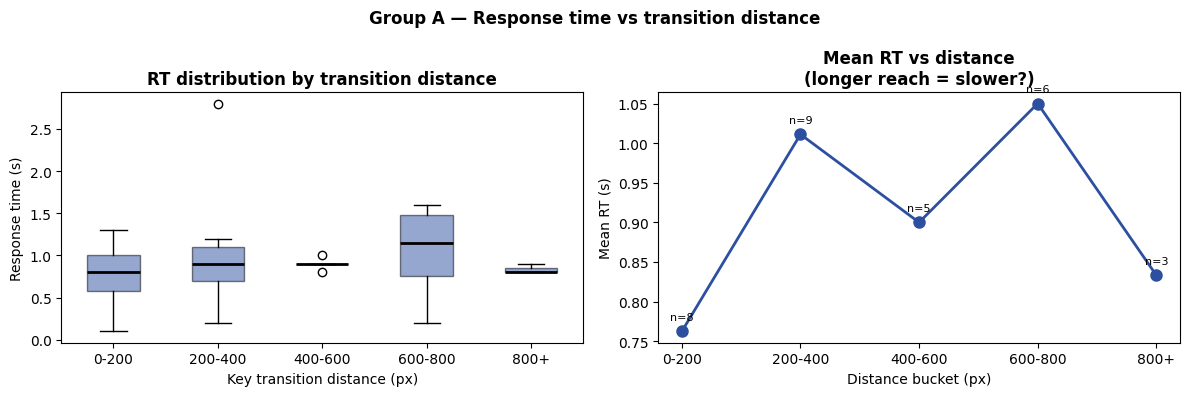


=== CLINICAL INSIGHT ===
If RT increases with distance: longer reaches require more motor planning time.
Flat relationship: user pre-plans movements (good motor strategy).

=== APP-MAKER SIGNAL ===
High-distance buckets with high RT AND low accuracy = those transitions are too hard.
Cap maximum transition distance at lower difficulty levels.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if movements.empty or keypresses.empty:
    print('No data.')
else:
    # FIX 1: Use np.inf as the upper bound so distances > 1200 fall into '800+'
    bins   = [0, 200, 400, 600, 800, np.inf]
    blabels= ['0-200','200-400','400-600','600-800','800+']
    movements2 = movements.copy()
    movements2['dist_bucket'] = pd.cut(movements2['distance'], bins=bins, labels=blabels)

    # match keypresses to movements by session + order (they are parallel arrays)
    rt_by_dist = {b: [] for b in blabels}
    for sess in movements2['session_id'].unique():
        mv = movements2[movements2['session_id']==sess].reset_index(drop=True)
        kp = keypresses[(keypresses['session_id']==sess) &
                        (keypresses['responsetime']>0)].reset_index(drop=True)
        n = min(len(mv), len(kp))
        for i in range(n):
            val = mv.loc[i, 'dist_bucket']
            
            # FIX 2: Safely skip any remaining NaN values (e.g., negative distances)
            if pd.isna(val):
                continue
                
            bucket = str(val)
            rt_by_dist[bucket].append(kp.loc[i, 'responsetime'])

    data_for_plot = [(b, rt_by_dist[b]) for b in blabels if rt_by_dist[b]]

    if not data_for_plot:
        print('Could not match movements to keypresses for this analysis.')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # box plot RT by distance
        axes[0].boxplot([d for _, d in data_for_plot],
                        labels=[b for b, _ in data_for_plot],
                        patch_artist=True,
                        medianprops=dict(color='black', lw=2),
                        boxprops=dict(facecolor='#2c4fa0', alpha=0.5))
        axes[0].set_xlabel('Key transition distance (px)')
        axes[0].set_ylabel('Response time (s)')
        axes[0].set_title('RT distribution by transition distance', fontweight='bold')

        # mean RT vs distance
        means = [np.mean(d) for _, d in data_for_plot]
        ns    = [len(d)     for _, d in data_for_plot]
        axes[1].plot([b for b,_ in data_for_plot], means, 'o-',
                     color='#2c4fa0', lw=2, markersize=8)
        for b, m, n in zip([b for b,_ in data_for_plot], means, ns):
            axes[1].annotate(f'n={n}', (b, m), textcoords='offset points',
                             xytext=(0, 8), ha='center', fontsize=8)
        axes[1].set_xlabel('Distance bucket (px)')
        axes[1].set_ylabel('Mean RT (s)')
        axes[1].set_title('Mean RT vs distance\n(longer reach = slower?)', fontweight='bold')

        plt.suptitle(GROUP_LABEL + ' — Response time vs transition distance', fontweight='bold')
        plt.tight_layout()
        save_fig(fig, 'fig10e_rt_vs_distance.png', OUT_DIR)
        plt.show()

        print('\n=== CLINICAL INSIGHT ===')
        print('If RT increases with distance: longer reaches require more motor planning time.')
        print('Flat relationship: user pre-plans movements (good motor strategy).')
        print('\n=== APP-MAKER SIGNAL ===')
        print('High-distance buckets with high RT AND low accuracy = those transitions are too hard.')
        print('Cap maximum transition distance at lower difficulty levels.')

## 6 · Fig 10f — RT variability (std) per session
Standard deviation of response time = motor consistency. Should decrease with practice.

Saved -> outputs/fig10f_rt_variability.png


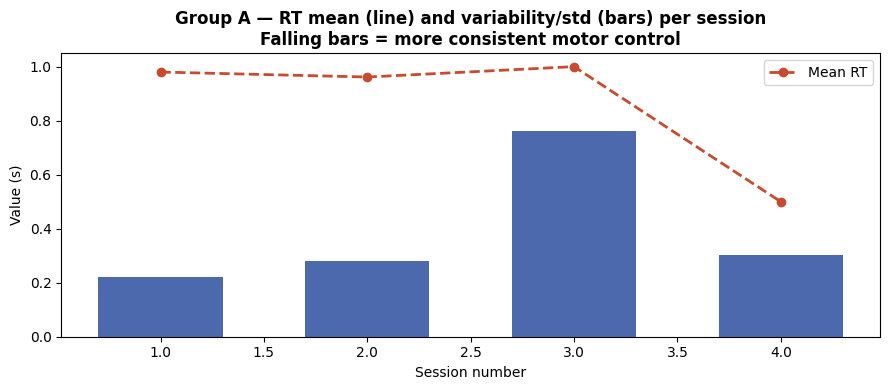


=== CLINICAL INSIGHT ===
High RT std = variable reflex speed = motor instability.
Tracking std over sessions is a sensitive measure of motor control improvement.
RT std often improves before mean RT — its an early recovery signal.

=== RESEARCH NOTE ===
Coefficient of variation (std/mean) normalises this across sessions with different speeds.
 session_num  avg_rt  rt_std  rt_cv
           1   0.980   0.223  0.227
           2   0.962   0.279  0.290
           3   1.000   0.763  0.763
           4   0.500   0.303  0.607


In [30]:
valid_sess2 = sessions[sessions['is_valid']].copy().reset_index(drop=True)
valid_sess2['session_num'] = range(1, len(valid_sess2)+1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(valid_sess2['session_num'], valid_sess2['rt_std'].fillna(0),
       color='#2c4fa0', alpha=0.85, width=0.6)
ax.plot(valid_sess2['session_num'], valid_sess2['avg_rt'],
        'o--', color='#c84b2f', lw=2, label='Mean RT')
ax.set_xlabel('Session number')
ax.set_ylabel('Value (s)')
ax.set_title(GROUP_LABEL + ' — RT mean (line) and variability/std (bars) per session\n'
             'Falling bars = more consistent motor control', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig(fig, 'fig10f_rt_variability.png', OUT_DIR)
plt.show()

print('\n=== CLINICAL INSIGHT ===')
print('High RT std = variable reflex speed = motor instability.')
print('Tracking std over sessions is a sensitive measure of motor control improvement.')
print('RT std often improves before mean RT — its an early recovery signal.')
print('\n=== RESEARCH NOTE ===')
print('Coefficient of variation (std/mean) normalises this across sessions with different speeds.')
valid_sess2['rt_cv'] = valid_sess2['rt_std'] / valid_sess2['avg_rt']
print(valid_sess2[['session_num','avg_rt','rt_std','rt_cv']].round(3).to_string(index=False))


## 7 · Export full movement metrics CSV

In [31]:
# Key transitions
if not movements.empty:
    movements.to_csv(os.path.join(OUT_DIR, 'piano_key_transitions.csv'), index=False)
    print('piano_key_transitions.csv saved')

# Finger movements
if not fingers.empty:
    fingers.to_csv(os.path.join(OUT_DIR, 'piano_finger_movements.csv'), index=False)
    print('piano_finger_movements.csv saved')

# Session summary with RT variability
valid_sess2.to_csv(os.path.join(OUT_DIR, 'piano_session_advanced.csv'), index=False)
print('piano_session_advanced.csv saved')

print('\n=== SUMMARY ===')
if not fingers.empty:
    tot = len(fingers)
    wrong_f = len(fingers[fingers['finger'] != fingers['expectedFinger']])
    print(f'Total finger presses: {tot}')
    print(f'Wrong finger used:    {wrong_f} ({wrong_f/tot*100:.1f}%)')
    print(f'Finger individuation rate: {(tot-wrong_f)/tot*100:.1f}%')
if not movements.empty:
    print(f'Total key transitions: {len(movements)}')
    print(f'Mean distance: {movements["distance"].mean():.0f}px')
    print(f'Max distance:  {movements["distance"].max():.0f}px')


piano_key_transitions.csv saved
piano_finger_movements.csv saved
piano_session_advanced.csv saved

=== SUMMARY ===
Total finger presses: 36
Wrong finger used:    11 (30.6%)
Finger individuation rate: 69.4%
Total key transitions: 32
Mean distance: 417px
Max distance:  930px
